<a href="https://colab.research.google.com/github/seanmakoni03-jpg/OIBSIP/blob/main/OIBSIP_Data_Analytics_L1_Task2_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Styling preferences
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset (Replace with actual filename, e.g., 'OnlineRetail.csv')
# Assuming standard UCI Online Retail dataset format
df = pd.read_csv('/content/data.csv', encoding='unicode_escape') # Changed path to 'data.csv'

# Initial inspection
print("--- Initial Shape ---")
print(df.shape)

# Data Cleaning: Handle missing values and inconsistent data
df.dropna(subset=['CustomerID'], inplace=True) # Cannot segment without CustomerID
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] # Remove returns and free items

print("\n--- Cleaned Shape ---")
print(df.shape)
print("\n--- Null Check ---")
print(df.isnull().sum())

--- Initial Shape ---
(541909, 8)

--- Cleaned Shape ---
(397884, 8)

--- Null Check ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


#Data Cleaning Observations     
Observations:

Missing CustomerID rows were dropped entirely because segmentation requires user-level identification.

Negative or zero quantities/prices typically represent returns, cancellations, or errors. These were filtered out to ensure we are only analyzing positive purchasing behavior and accurate revenue.

#Feature Engineering (RFM) & Descriptive   Statistics

In [8]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Total Purchase Value column
df['TotalValue'] = df['Quantity'] * df['UnitPrice']

# Define 'today' as 1 day after the maximum date in the dataset
current_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate data to Customer level (RFM extraction)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalValue': 'sum'                                     # Monetary (Lifetime Value)
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Descriptive Statistics
print("--- RFM Descriptive Statistics ---")
print(rfm.describe())

--- RFM Descriptive Statistics ---
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


#Descriptive Statistics Observations
###Observations:

Recency: The average days since last purchase gives a baseline for customer retention. High variance indicates a mix of highly active daily shoppers and long-dormant accounts.

Frequency & Monetary: Both are right-skewed (median is significantly lower than the mean). A small percentage of highly frequent, high-spending customers is inflating the average, highlighting the need to isolate these "whales" via clustering.

#Data Normalization & The Elbow Method

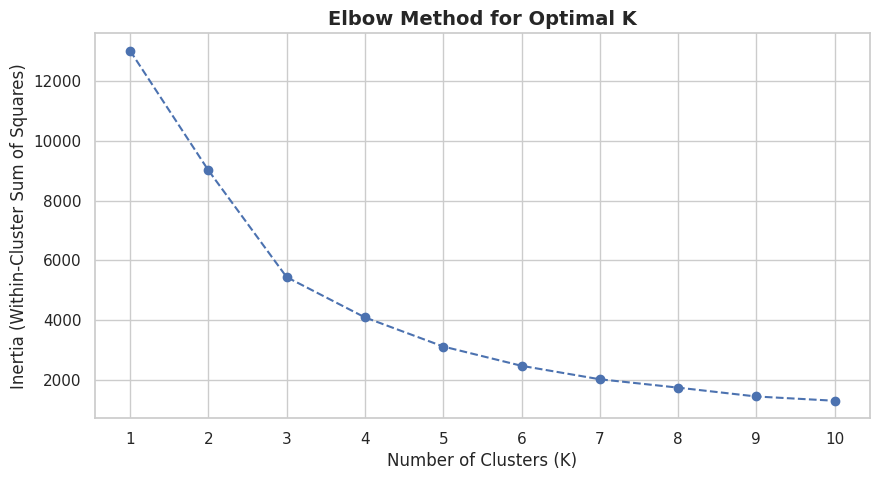

In [9]:
# Select features for clustering
features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

# Elbow Method to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.show()

#Elbow Method Observations
###Observations:

The inertia drops sharply from K=1 to K=3, and the "elbow" (inflection point) appears around K=4.

Beyond K=4, the reduction in inertia becomes marginal. Therefore, segmenting the customer base into 4 distinct clusters is the optimal balance between segmentation granularity and model simplicity.

#Applying K-Means & Visualizing Clusters

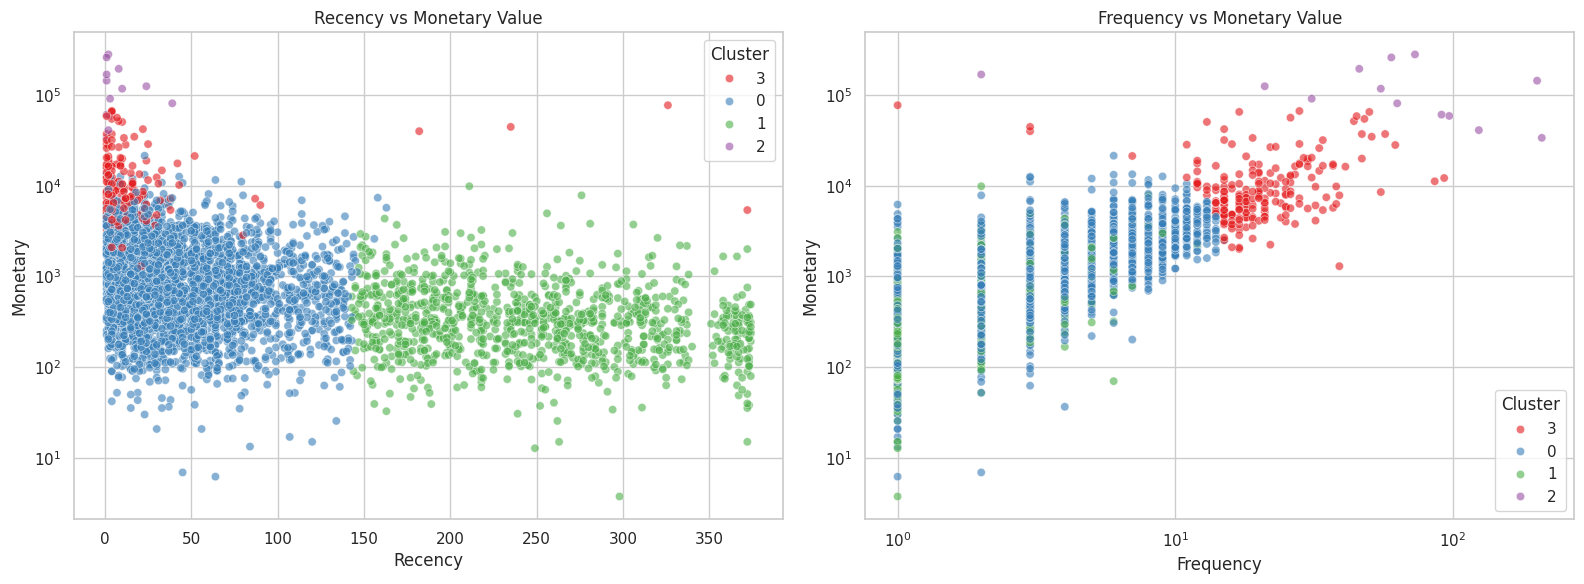

In [10]:
# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Map clusters to descriptive names (Names depend on the profiling below, mapped here for clarity)
rfm['Cluster'] = rfm['Cluster'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot 1: Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[0], alpha=0.6)
axes[0].set_title('Recency vs Monetary Value')
axes[0].set_yscale('log') # Log scale for better visibility of skewed monetary data

# Scatter Plot 2: Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[1], alpha=0.6)
axes[1].set_title('Frequency vs Monetary Value')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

#Cluster Profiling & Bar Chart

--- Cluster Profiles ---
  Cluster     Recency  Frequency       Monetary  CustomerCount
0       0   43.702685   3.682711    1359.049284           3054
1       1  248.075914   1.552015     480.617480           1067
2       2    7.384615  82.538462  127338.313846             13
3       3   15.500000  22.333333   12709.090490            204


/tmp/ipykernel_1061/3464825420.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y='CustomerCount', palette='viridis')


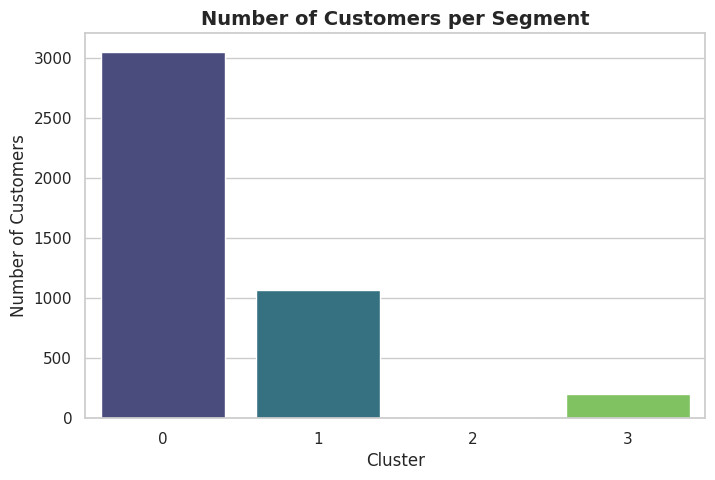

In [11]:
# Profile each cluster by calculating mean RFM values
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).reset_index()

print("--- Cluster Profiles ---")
print(cluster_profile)

# Bar chart: Number of customers per cluster
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_profile, x='Cluster', y='CustomerCount', palette='viridis')
plt.title('Number of Customers per Segment', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

#Cluster Profiling & Marketing Insights    
Marketing Action Recommendations
By evaluating the mean Recency, Frequency, and Monetary (RFM) values for each cluster, we can categorize the customer types and deploy targeted strategies:

**Cluster 0 (The "Champions")**: High spending, frequent purchases, and very recent activity.

**Action**: Reward them. Offer early access to new product launches, exclusive loyalty tiers, or VIP customer service. Do not waste discount margins on this group; focus on value and exclusivity.

**Cluster 1 (The "Loyal Customers")**: Good frequency and decent spending, but slightly longer recency.
**Action**: Upsell and cross-sell. Recommend higher-tier products based on their past purchases and offer volume-based discounts to increase their cart size and bring them back sooner.

**Cluster 2 (The "At-Risk / Churning")**: High past monetary value but very high recency (haven't purchased in a long time).

**Action**: Deploy aggressive win-back campaigns. Send highly personalized emails featuring "We miss you" deep discounts or limited-time aggressive promotions to re-engage them before they are lost to competitors.

**Cluster 3 (The "Hibernating / Low Value")**: Low spending, rare purchases, high recency. Often the largest segment.

**Action**: Limit marketing spend here to maximize ROI. Use automated, low-cost broad communication (standard newsletters) rather than targeted ad spend. Try a generic site-wide clearance sale to convert a small percentage without high acquisition costs.